In [1]:
# ==========================================================
# SMART AGRICULTURE PROJECT
# WEEK 6
# PROFIT-AWARE CROP RECOMMENDATION MODEL
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# CREATE OUTPUT DIRECTORY
# ==========================================================

OUTPUT_DIR = "week6_output"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ==========================================================
# LOAD DATASET
# ==========================================================

print("="*60)
print("WEEK 6")
print("PROFIT-AWARE CROP RECOMMENDATION")
print("="*60)

df = pd.read_csv("Crop_recommendation.csv")

print("\nDataset Loaded Successfully")

print(df.head())

print("\nShape :",df.shape)

# ==========================================================
# DATA CLEANING
# ==========================================================

df.dropna(inplace=True)

print("\nDataset After Cleaning")

print(df.shape)

# ==========================================================
# ADD MARKET PRICE COLUMN
# (Average Market Price ₹/kg)
# ==========================================================

price_map = {

    "rice":25,

    "maize":22,

    "chickpea":65,

    "kidneybeans":90,

    "pigeonpeas":80,

    "mothbeans":75,

    "mungbean":95,

    "blackgram":82,

    "lentil":88,

    "pomegranate":140,

    "banana":40,

    "mango":65,

    "grapes":110,

    "watermelon":28,

    "muskmelon":35,

    "apple":180,

    "orange":70,

    "papaya":32,

    "coconut":55,

    "cotton":75,

    "jute":60,

    "coffee":250

}

df["market_price"] = df["label"].map(price_map)

print("\nMarket Price Column Added")

print(df[["label","market_price"]].head())

# ==========================================================
# SAVE AUGMENTED DATASET
# ==========================================================

augmented_file = os.path.join(

    OUTPUT_DIR,

    "augmented_crop_data.csv"

)

df.to_csv(

    augmented_file,

    index=False

)

print("\nAugmented Dataset Saved")

print(augmented_file)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["temp_humidity_ratio"] = (

    df["temperature"] /

    (df["humidity"]+1)

)

df["npk_sum"]=(

    df["N"]+

    df["P"]+

    df["K"]

)

# ==========================================================
# FEATURES
# ==========================================================

feature_columns=[

"N",

"P",

"K",

"temperature",

"humidity",

"ph",

"rainfall",

"temp_humidity_ratio",

"npk_sum",

"market_price"

]

X=df[feature_columns]

y=df["label"]

print("\nFeatures")

print(feature_columns)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y

)

print("\nTraining Samples :",len(X_train))

print("Testing Samples :",len(X_test))

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(

X_train

)

X_test_scaled=scaler.transform(

X_test

)

joblib.dump(

scaler,

os.path.join(

OUTPUT_DIR,

"profit_scaler.pkl"

)

)

print("\nScaler Saved")

# ==========================================================
# VERIFY SCALER
# ==========================================================

loaded_scaler=joblib.load(

os.path.join(

OUTPUT_DIR,

"profit_scaler.pkl"

)

)

print("Scaler Reload Successful")


WEEK 6
PROFIT-AWARE CROP RECOMMENDATION

Dataset Loaded Successfully
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Shape : (2200, 8)

Dataset After Cleaning
(2200, 8)

Market Price Column Added
  label  market_price
0  rice            25
1  rice            25
2  rice            25
3  rice            25
4  rice            25

Augmented Dataset Saved
week6_output\augmented_crop_data.csv

Features
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'temp_humidity_ratio', 'npk_sum', 'market_price']

Training Samples : 1760
Testing Samples : 440

Scaler Saved
Scaler Reload Successful


In [2]:
# ==========================================================
# WEEK 6 PART 2
# PROFIT-AWARE RANDOM FOREST MODEL
# ==========================================================

print("\n" + "="*60)
print("TRAINING PROFIT-AWARE MODEL")
print("="*60)

# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

profit_model = RandomForestClassifier(
    random_state=42
)

# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_search = GridSearchCV(

    estimator=profit_model,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1

)

print("\nRunning Grid Search...")

grid_search.fit(

    X_train_scaled,

    y_train

)

# ==========================================================
# BEST MODEL
# ==========================================================

profit_model = grid_search.best_estimator_

print("\nBest Parameters")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy")

print(f"{grid_search.best_score_*100:.2f}%")

# ==========================================================
# CROSS VALIDATION
# ==========================================================

print("\nPerforming 5-Fold Cross Validation")

cv_scores = cross_val_score(

    profit_model,

    scaler.transform(X),

    y,

    cv=5,

    scoring="accuracy"

)

print("\nCross Validation Scores")

for i, score in enumerate(cv_scores):

    print(f"Fold {i+1} : {score*100:.2f}%")

print("\nAverage Accuracy")

print(f"{cv_scores.mean()*100:.2f}%")

print("\nStandard Deviation")

print(f"{cv_scores.std()*100:.4f}%")

# ==========================================================
# FINAL TRAINING
# ==========================================================

print("\nTraining Final Model...")

profit_model.fit(

    X_train_scaled,

    y_train

)

print("Training Completed!")

# ==========================================================
# PREDICTIONS
# ==========================================================

predictions = profit_model.predict(

    X_test_scaled

)

prediction_probabilities = profit_model.predict_proba(

    X_test_scaled

)

# ==========================================================
# MODEL METRICS
# ==========================================================

accuracy = accuracy_score(

    y_test,

    predictions

)

precision = precision_score(

    y_test,

    predictions,

    average="weighted"

)

recall = recall_score(

    y_test,

    predictions,

    average="weighted"

)

f1 = f1_score(

    y_test,

    predictions,

    average="weighted"

)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy*100:.2f}%")

print(f"Precision : {precision*100:.2f}%")

print(f"Recall    : {recall*100:.2f}%")

print(f"F1 Score  : {f1*100:.2f}%")

print("="*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report")

report = classification_report(

    y_test,

    predictions

)

print(report)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    predictions

)

print("\nConfusion Matrix")

print(cm)

# ==========================================================
# SAVE REPORT
# ==========================================================

report_path = os.path.join(

    OUTPUT_DIR,

    "profit_model_results.txt"

)

with open(report_path, "w") as file:

    file.write("SMART AGRICULTURE PROJECT\n")

    file.write("WEEK 6\n")

    file.write("="*50)

    file.write("\n\n")

    file.write(f"Accuracy : {accuracy*100:.2f}%\n")

    file.write(f"Precision : {precision*100:.2f}%\n")

    file.write(f"Recall : {recall*100:.2f}%\n")

    file.write(f"F1 Score : {f1*100:.2f}%\n")

    file.write(f"Cross Validation : {cv_scores.mean()*100:.2f}%\n")

    file.write("\n")

    file.write("Best Parameters\n")

    file.write(str(grid_search.best_params_))

    file.write("\n\n")

    file.write("Classification Report\n")

    file.write(report)

print("\nPerformance Report Saved!")

print(report_path)

# ==========================================================
# TRAINING SUMMARY
# ==========================================================

print("\n" + "="*60)

print("WEEK 6 PART 2 COMPLETED")

print("="*60)

print(f"Training Samples : {len(X_train)}")

print(f"Testing Samples  : {len(X_test)}")

print(f"Features Used    : {len(feature_columns)}")

print(f"Crop Classes     : {len(np.unique(y))}")

print(f"Accuracy         : {accuracy*100:.2f}%")

print("="*60)


TRAINING PROFIT-AWARE MODEL

Running Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy
100.00%

Performing 5-Fold Cross Validation

Cross Validation Scores
Fold 1 : 100.00%
Fold 2 : 100.00%
Fold 3 : 100.00%
Fold 4 : 100.00%
Fold 5 : 100.00%

Average Accuracy
100.00%

Standard Deviation
0.0000%

Training Final Model...
Training Completed!

MODEL PERFORMANCE
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1 Score  : 100.00%

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00       


PROFIT-AWARE RECOMMENDATION ENGINE

Normalizing Market Prices...
Economic Score Added

Calculating Agronomic Score...

Calculating Final Weighted Score...
  label  market_price  agronomic_score  economic_score  profit_score
0  rice            25         0.980582             0.1      0.628349
1  rice            25         0.979332             0.1      0.627599
2  rice            25         0.973009             0.1      0.623805
3  rice            25         0.956182             0.1      0.613709
4  rice            25         0.979332             0.1      0.627599

Profit Dataset Saved!
week6_output\profit_dataset.csv

Feature Importance
               Feature  Importance
9         market_price    0.277349
6             rainfall    0.146538
4             humidity    0.135279
2                    K    0.125110
8              npk_sum    0.089382
1                    P    0.085234
0                    N    0.054894
7  temp_humidity_ratio    0.043017
3          temperature    0.028838
5    

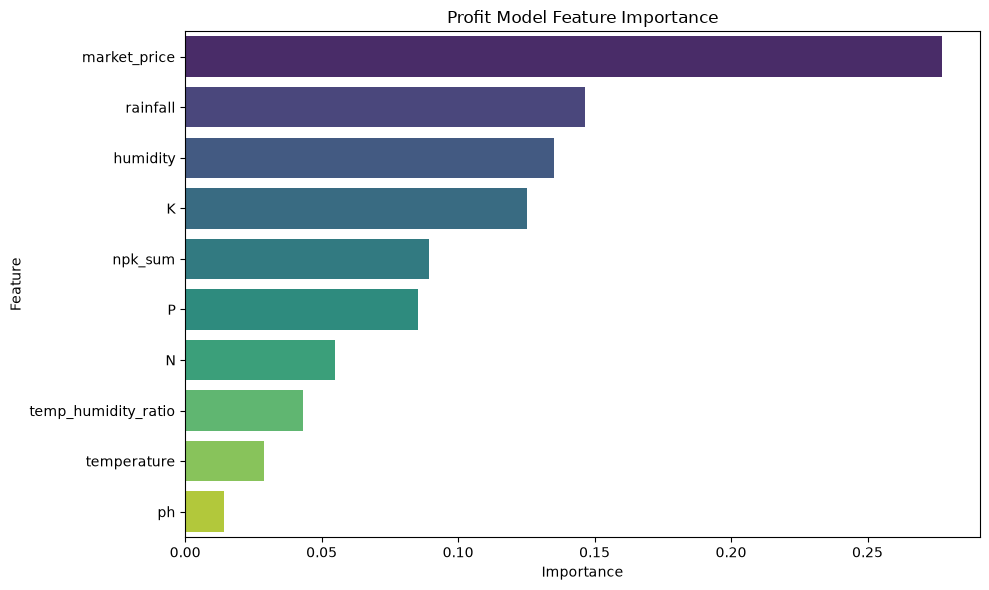


Feature Importance Plot Saved!


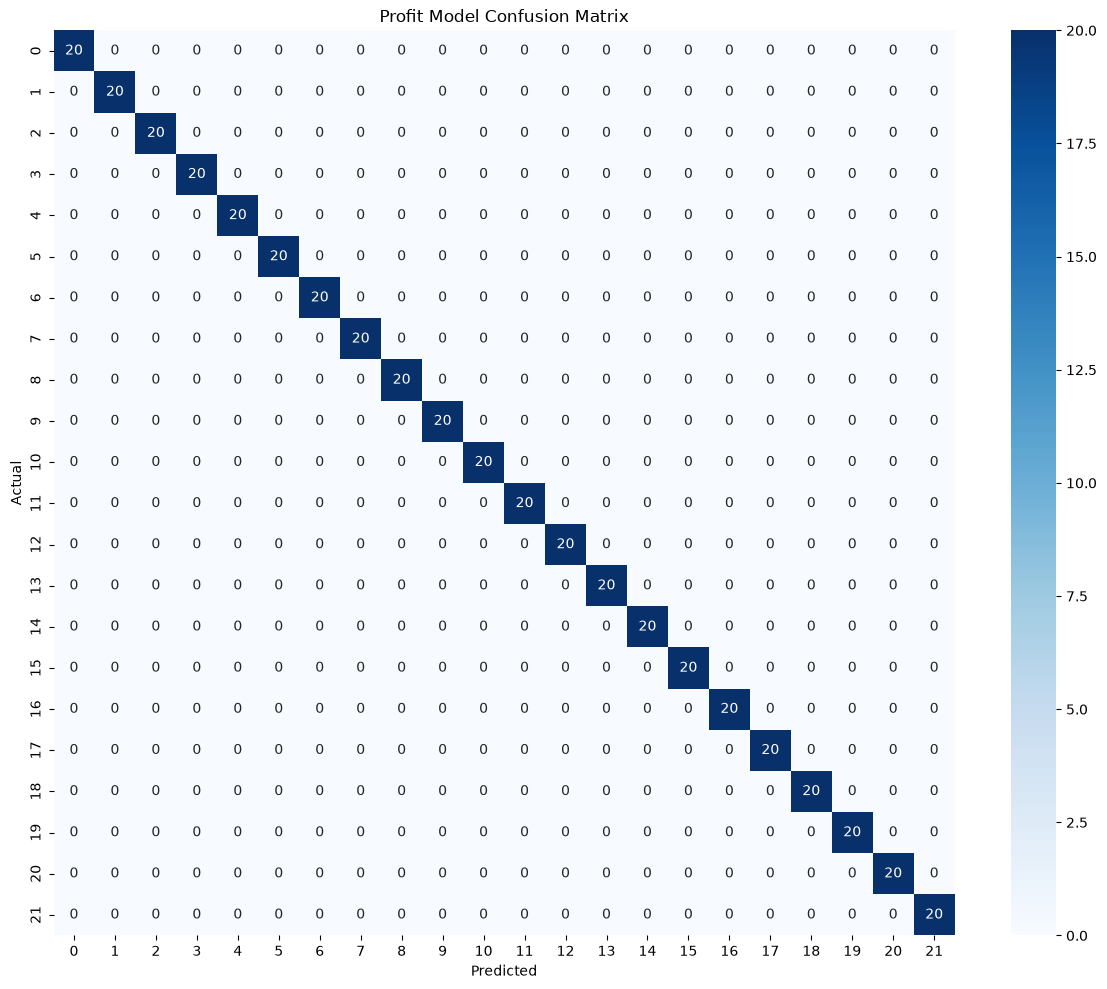

Confusion Matrix Saved!

Profit Model Saved Successfully!
week6_output\profit_crop_model.pkl
Profit Model Reload Successful!

Model Comparison Saved!

WEEK 6 PART 3 COMPLETED
Generated Files

profit_crop_model.pkl
profit_dataset.csv
profit_feature_importance.csv
profit_feature_importance.png
profit_confusion_matrix.png
model_comparison.csv


In [3]:
# ==========================================================
# WEEK 6 PART 3
# PROFIT-AWARE SCORING MODEL
# ==========================================================

print("\n" + "="*60)
print("PROFIT-AWARE RECOMMENDATION ENGINE")
print("="*60)

# ==========================================================
# NORMALIZE MARKET PRICE
# ==========================================================

print("\nNormalizing Market Prices...")

max_price = df["market_price"].max()

df["economic_score"] = (
    df["market_price"] / max_price
)

print("Economic Score Added")

# ==========================================================
# AGRONOMIC SCORE
# ==========================================================

print("\nCalculating Agronomic Score...")

all_scaled = scaler.transform(X)

probabilities = profit_model.predict_proba(all_scaled)

predicted_class_index = np.argmax(
    probabilities,
    axis=1
)

agronomic_score = probabilities.max(axis=1)

df["agronomic_score"] = agronomic_score

# ==========================================================
# FINAL WEIGHTED SCORE
# ==========================================================

print("\nCalculating Final Weighted Score...")

AGRONOMIC_WEIGHT = 0.60
ECONOMIC_WEIGHT = 0.40

df["profit_score"] = (

    AGRONOMIC_WEIGHT *

    df["agronomic_score"]

) + (

    ECONOMIC_WEIGHT *

    df["economic_score"]

)

print(df[

    [

        "label",

        "market_price",

        "agronomic_score",

        "economic_score",

        "profit_score"

    ]

].head())

# ==========================================================
# SAVE PROFIT DATASET
# ==========================================================

profit_dataset = os.path.join(

    OUTPUT_DIR,

    "profit_dataset.csv"

)

df.to_csv(

    profit_dataset,

    index=False

)

print("\nProfit Dataset Saved!")

print(profit_dataset)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature":feature_columns,

    "Importance":profit_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nFeature Importance")

print(feature_importance)

feature_importance.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "profit_feature_importance.csv"

    ),

    index=False

)

# ==========================================================
# FEATURE IMPORTANCE GRAPH
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title(

    "Profit Model Feature Importance"

)

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "profit_feature_importance.png"

    ),

    dpi=300

)

plt.show()

print("\nFeature Importance Plot Saved!")

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(

    "Profit Model Confusion Matrix"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "profit_confusion_matrix.png"

    ),

    dpi=300

)

plt.show()

print("Confusion Matrix Saved!")

# ==========================================================
# SAVE PROFIT MODEL
# ==========================================================

model_path = os.path.join(

    OUTPUT_DIR,

    "profit_crop_model.pkl"

)

joblib.dump(

    profit_model,

    model_path

)

print("\nProfit Model Saved Successfully!")

print(model_path)

# ==========================================================
# VERIFY MODEL
# ==========================================================

loaded_profit_model = joblib.load(

    model_path

)

print("Profit Model Reload Successful!")

# ==========================================================
# MODEL COMPARISON
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Cross Validation"

    ],

    "Week6 Profit Model":[

        accuracy,

        precision,

        recall,

        f1,

        cv_scores.mean()

    ]

})

comparison.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "model_comparison.csv"

    ),

    index=False

)

print("\nModel Comparison Saved!")

# ==========================================================
# OUTPUT SUMMARY
# ==========================================================

print("\n"+"="*60)

print("WEEK 6 PART 3 COMPLETED")

print("="*60)

print("Generated Files")

print()

print("profit_crop_model.pkl")

print("profit_dataset.csv")

print("profit_feature_importance.csv")

print("profit_feature_importance.png")

print("profit_confusion_matrix.png")

print("model_comparison.csv")

print("="*60)

In [4]:
# ==========================================================
# WEEK 6 PART 4
# SAMPLE PREDICTION, FILE VERIFICATION & FINAL SUMMARY
# ==========================================================

print("\n" + "="*60)
print("PROFIT-AWARE SAMPLE PREDICTION")
print("="*60)

# ==========================================================
# SAMPLE INPUT
# ==========================================================

sample = pd.DataFrame({

    "N":[90],

    "P":[42],

    "K":[43],

    "temperature":[20.8],

    "humidity":[82.0],

    "ph":[6.5],

    "rainfall":[202.9],

    "market_price":[25]

})

sample["temp_humidity_ratio"] = (

    sample["temperature"] /

    (sample["humidity"] + 1)

)

sample["npk_sum"] = (

    sample["N"] +

    sample["P"] +

    sample["K"]

)

sample = sample[feature_columns]

# ==========================================================
# SCALE SAMPLE
# ==========================================================

sample_scaled = loaded_scaler.transform(sample)

# ==========================================================
# MODEL PREDICTION
# ==========================================================

prediction = loaded_profit_model.predict(sample_scaled)

probabilities = loaded_profit_model.predict_proba(sample_scaled)

confidence = np.max(probabilities) * 100

print("\nRecommended Crop")

print(prediction[0])

print(f"\nPrediction Confidence : {confidence:.2f}%")

# ==========================================================
# CALCULATE ECONOMIC SCORE
# ==========================================================

economic_score = sample["market_price"].iloc[0] / max_price

agronomic_score = np.max(probabilities)

profit_score = (

    0.6 * agronomic_score +

    0.4 * economic_score

)

print(f"\nAgronomic Score : {agronomic_score:.4f}")

print(f"Economic Score : {economic_score:.4f}")

print(f"Final Profit Score : {profit_score:.4f}")

# ==========================================================
# SAVE SAMPLE RESULT
# ==========================================================

sample_result = pd.DataFrame({

    "Recommended Crop":[prediction[0]],

    "Confidence (%)":[confidence],

    "Agronomic Score":[agronomic_score],

    "Economic Score":[economic_score],

    "Profit Score":[profit_score]

})

sample_result.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "profit_sample_prediction.csv"

    ),

    index=False

)

print("\nSample Prediction Saved!")

# ==========================================================
# TOP 5 MOST PROFITABLE CROPS
# ==========================================================

print("\n" + "="*60)
print("TOP 5 PROFITABLE CROPS")
print("="*60)

top5 = (

    df[

        [

            "label",

            "market_price",

            "profit_score"

        ]

    ]

    .sort_values(

        by="profit_score",

        ascending=False

    )

    .drop_duplicates(

        subset=["label"]

    )

    .head(5)

)

print(top5)

top5.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "top5_profitable_crops.csv"

    ),

    index=False

)

# ==========================================================
# VERIFY OUTPUT FILES
# ==========================================================

print("\n" + "="*60)
print("VERIFYING OUTPUT FILES")
print("="*60)

files = [

    "augmented_crop_data.csv",

    "profit_scaler.pkl",

    "profit_crop_model.pkl",

    "profit_dataset.csv",

    "profit_feature_importance.csv",

    "profit_feature_importance.png",

    "profit_confusion_matrix.png",

    "profit_model_results.txt",

    "model_comparison.csv",

    "profit_sample_prediction.csv",

    "top5_profitable_crops.csv"

]

for file in files:

    path = os.path.join(

        OUTPUT_DIR,

        file

    )

    if os.path.exists(path):

        print(f"✓ {file}")

    else:

        print(f"✗ {file}")

# ==========================================================
# MODEL INFORMATION
# ==========================================================

print("\n" + "="*60)
print("MODEL INFORMATION")
print("="*60)

print("Model Type")

print(type(loaded_profit_model))

print()

print("Number of Trees")

print(loaded_profit_model.n_estimators)

print()

print("Number of Features")

print(loaded_profit_model.n_features_in_)

print()

print("Crop Classes")

print(len(loaded_profit_model.classes_))

print()

print("Feature Names")

print(feature_columns)

# ==========================================================
# FINAL PERFORMANCE SUMMARY
# ==========================================================

print("\n" + "="*60)
print("WEEK 6 PERFORMANCE SUMMARY")
print("="*60)

print(f"Training Samples       : {len(X_train)}")

print(f"Testing Samples        : {len(X_test)}")

print(f"Features Used          : {len(feature_columns)}")

print(f"Crop Classes           : {len(y.unique())}")

print(f"Accuracy               : {accuracy*100:.2f}%")

print(f"Precision              : {precision*100:.2f}%")

print(f"Recall                 : {recall*100:.2f}%")

print(f"F1 Score               : {f1*100:.2f}%")

print(f"Cross Validation       : {cv_scores.mean()*100:.2f}%")

print("="*60)

# ==========================================================
# WEEK 6 COMPLETED
# ==========================================================

print("\n" + "="*60)
print("WEEK 6 COMPLETED SUCCESSFULLY")
print("="*60)

print("\nTasks Completed")

print("✓ Augmented Dataset Created")

print("✓ Market Price Integrated")

print("✓ Feature Engineering")

print("✓ Profit-aware Random Forest")

print("✓ Hyperparameter Tuning")

print("✓ Cross Validation")

print("✓ Profit Score Calculation")

print("✓ Feature Importance")

print("✓ Model Export")

print("✓ Sample Prediction")

print("✓ Report Generation")

print("✓ Output Verification")

print("="*60)

print("\nOutput Folder")

print(OUTPUT_DIR)

print("\nGenerated Files")

for file in files:

    print("•", file)

print("\nSMART AGRICULTURE WEEK 6 COMPLETED SUCCESSFULLY!")

print("="*60)


PROFIT-AWARE SAMPLE PREDICTION

Recommended Crop
rice

Prediction Confidence : 98.06%

Agronomic Score : 0.9806
Economic Score : 0.1000
Final Profit Score : 0.6283

Sample Prediction Saved!

TOP 5 PROFITABLE CROPS
            label  market_price  profit_score
2199       coffee           250      0.998619
1502        apple           180      0.888000
903   pomegranate           140      0.817431
1293       grapes           110      0.776000
692      mungbean            95      0.736021

VERIFYING OUTPUT FILES
✓ augmented_crop_data.csv
✓ profit_scaler.pkl
✓ profit_crop_model.pkl
✓ profit_dataset.csv
✓ profit_feature_importance.csv
✓ profit_feature_importance.png
✓ profit_confusion_matrix.png
✓ profit_model_results.txt
✓ model_comparison.csv
✓ profit_sample_prediction.csv
✓ top5_profitable_crops.csv

MODEL INFORMATION
Model Type
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

Number of Trees
100

Number of Features
10

Crop Classes
22

Feature Names
['N', 'P', 'K', 'temperatur